## IntelliSpam - Email Spam Detection

This project focuses on building a machine learning model that can classify emails as spam or not spam using natural language processing and logistic regression.
The dataset contains labeled email messages where the target variable indicates whether an email is spam (1) or not spam (0).

The dataset consists of raw email text along with a few engineered features derived from it.
The main column is text, which contains the email content.
From this, additional features are created such as number of words, total character length, count of exclamation marks, number of digits, and number of dollar signs.

## Libraries Used

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib

import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [ ]:
df = pd.read_csv("emails.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [ ]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [ ]:
df["spam"].value_counts()

spam
0    4360
1    1368
Name: count, dtype: int64

## Text Preprocessing

### Remove Punctuation







In [ ]:
import string


def remove_punc(text):
    return text.translate(str.maketrans("", "", "!\"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~"))


df["text"] = df["text"].apply(remove_punc)

### Feature Engineering

In [ ]:
def extract_features(text):
    words = len(text.split())
    length = len(text)
    exclamations = text.count("!")
    digits = sum(char.isdigit() for char in text)
    dollar = text.count("$")

    return [words, length, exclamations, digits, dollar]


extra_features = df["text"].apply(extract_features)

In [ ]:
extra_features = pd.DataFrame(
    extra_features.tolist(),
    columns=["words", "length", "exclamations", "digits", "dollar"]
)

## Data Visualization

### Email Length Distribution

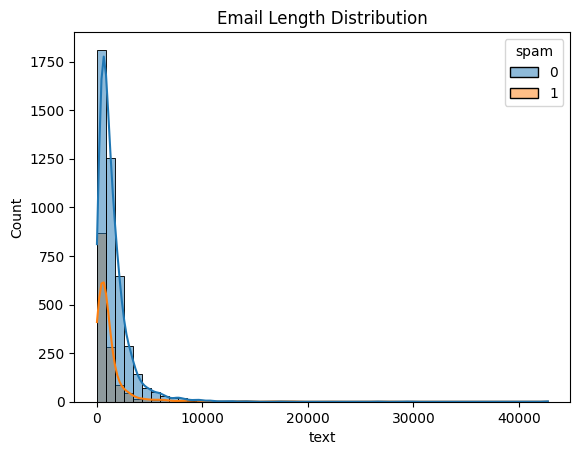

In [ ]:
length_email = df["text"].apply(len)

sns.histplot(data=df, x=length_email, hue="spam", bins=50, kde=True)
plt.title("Email Length Distribution")
plt.show()

### Common words in spam emails

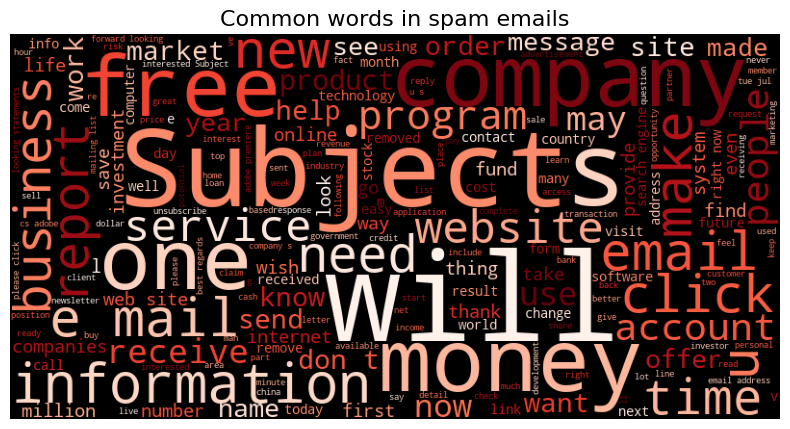

In [ ]:
from wordcloud import WordCloud
spam_text = " ".join(df[df["spam"] == 1]["text"])

wordcloud_spam = WordCloud(
    width=800,
    height=400,
    background_color="black",
    colormap="Reds"
).generate(spam_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_spam)
plt.axis("off")
plt.title("Common words in spam emails", fontsize=16)
plt.show()

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

## NLP

In [ ]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
stop_words = set(stopwords.words("english"))

In [ ]:
def remove(text):
    words = word_tokenize(text)
    cleaned = []
    for i in words:
        if i not in stop_words:
            cleaned.append(i)
    return " ".join(cleaned)


df["text"] = df["text"].apply(remove)

## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## TF-IDF Vectorization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

In [ ]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## Combine Features

In [ ]:
from scipy.sparse import hstack

extra_train = pd.DataFrame(X_train.apply(extract_features).tolist())
extra_test = pd.DataFrame(X_test.apply(extract_features).tolist())

X_train_combined = hstack([X_train_tfidf, extra_train.values])
X_test_combined = hstack([X_test_tfidf, extra_test.values])

## Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced")

In [ ]:
model.fit(X_train_combined, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [ ]:
y_pred = model.predict(X_test_combined)

## Evaluation

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

## Model Pipeline

In [ ]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", LogisticRegression(class_weight = "balanced"))
])

0


In [ ]:
joblib.dump(pipe, 'EmailClassifier.pkl')

['EmailClassifier.pkl']